In [1]:
# loading libraries for data manipulation
import numpy as np
import pandas as pd

# loading libraries for data visualization
import matplotlib.pyplot as plt
from plotnine import *

# import tensorflow and keras packages

import tensorflow as tf
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore')

Let's create a neural network to classify digits from images. The MNIST digits dataset contains 70K images of digits (0-9).

In [2]:
# Load MNIST data from keras.datasets
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()

(28, 28)


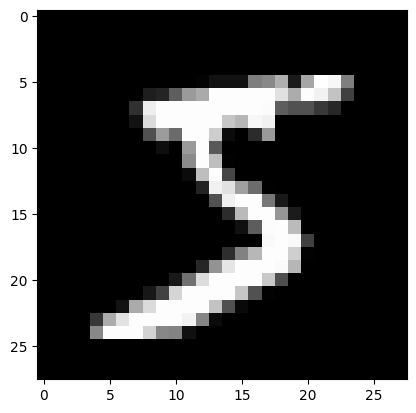

In [3]:
# Print one example observation
print(X_train_mnist[0].shape)
plt.imshow(X_train_mnist[0], cmap='gray')
plt.show()


While each observation is a 28x28 pixel image, it can be converted into a long 1 dimensional vector of greyscale values. 

In [4]:
# Preprocess: flatten images and normalize pixel values
# reshape(-1,28x28) flattens each image into a 1-dimensional vector of length 28*28
# the -1 here means all items in the object (no need to specify exact amount)
# /255.0 scales a greyscale value between [0-255] into [0-1]  
X_train_mnist = X_train_mnist.reshape(-1, 28*28).astype('float32') / 255.0

print(X_train_mnist[0].shape)

(784,)


Let's build a deep neural network with 1 hidden layers. The softmax function is used for multi-class classification problems. The output layer has the same number of units as the classes, in this instance 10.

In [7]:
# define function to construct architecture
def create_model():
    # fully connected NNet with 1 hidden layer of 128 nodes
    model = keras.Sequential([
        keras.layers.Dense(128,activation='relu',input_shape=(784,)),
        keras.layers.Dense(10,activation='softmax') # output layer
    ])

    return model

We can now define our optimizer. We also need to define a learning rate and initialize our model.

In [14]:
lr = 0.05

optimizer_function = keras.optimizers.SGD(lr)

mnist_sgd_02 = create_model()

Now, we will compile and train our model for 5 epochs. The loss function here is sparse_categorical_crossentropy. This is a variation of categorical_crossentropy when the class is a numerical value instead of a one-hot encoded vector. 

In [15]:

mnist_sgd_02.compile(optimizer=optimizer_function,
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

mnist_sgd_02.fit(X_train_mnist, y_train_mnist, epochs=5,batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 362us/step - accuracy: 0.8953 - loss: 0.3753
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 372us/step - accuracy: 0.9421 - loss: 0.2033
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 367us/step - accuracy: 0.9567 - loss: 0.1531
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 362us/step - accuracy: 0.9654 - loss: 0.1235
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 374us/step - accuracy: 0.9707 - loss: 0.1040


Let's view the architecture of our model

In [16]:
mnist_sgd_02.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,772 (397.55 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

To predict, we load up an image and run it through the model, getting a probability across all classes as a result. 

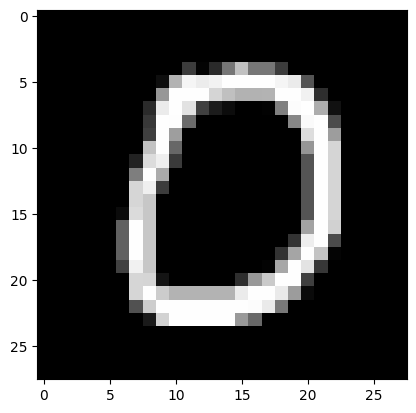

In [17]:
plt.imshow(X_test_mnist[10], cmap='gray')
plt.show()

In [18]:
input_image = X_test_mnist[10].reshape(1, 28*28)/255.0

predictions = mnist_sgd_02.predict(input_image)

for i in range(10):
    print(f"Probability of digit {i}: {predictions[0][i]:.4f}") 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Probability of digit 0: 0.9999
Probability of digit 1: 0.0000
Probability of digit 2: 0.0001
Probability of digit 3: 0.0000
Probability of digit 4: 0.0000
Probability of digit 5: 0.0000
Probability of digit 6: 0.0000
Probability of digit 7: 0.0000
Probability of digit 8: 0.0000
Probability of digit 9: 0.0000


Try different variations of number of hidden layers (and units), epochs, optimizers, and batch sizes. 

- SGD: keras.optimizers.SGD(learning_rate=lr)
- Momentum: keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
- AdaGrad: keras.optimizers.Adagrad(learning_rate=lr)
- RMSProp: keras.optimizers.RMSprop(learning_rate=lr)
- Adam: keras.optimizers.Adam(learning_rate=lr)

In [ ]:
lr = 
optimizer_name = 
optimizer_function = 

mnist_model_03 = create_model()

mnist_model_03.compile()

mnist_model_03.fit()


Let's apply all optimizers to the dataset to see differences in training. 

In [5]:
# setting up some variables
model_history = {}
lr = 0.02

# reshaping testing data
X_test_mnist = X_test_mnist.reshape(-1, 28*28).astype('float32') / 255.0

In [8]:
# dictionary of optimizers
optimizers = {'SGD':keras.optimizers.SGD(lr),
              'Momentum':keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
              'AdaGrad':keras.optimizers.Adagrad(learning_rate=lr),
              'RMSProp':keras.optimizers.RMSprop(learning_rate=lr),
              'Adam':keras.optimizers.Adam(learning_rate=lr)}

# for each optimizer, train a different model
for name,func in optimizers.items():
    print(f"\nTraining with {name}")
    model = create_model()
    model.compile(optimizer=func,
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
    history = model.fit(X_train_mnist, y_train_mnist, 
                        epochs=5,
                        batch_size=32, 
                        verbose=0,
                        validation_data=(X_test_mnist, y_test_mnist)
                        )
    model_history[name] = history.history


Training with SGD

Training with Momentum

Training with AdaGrad

Training with RMSProp

Training with Adam


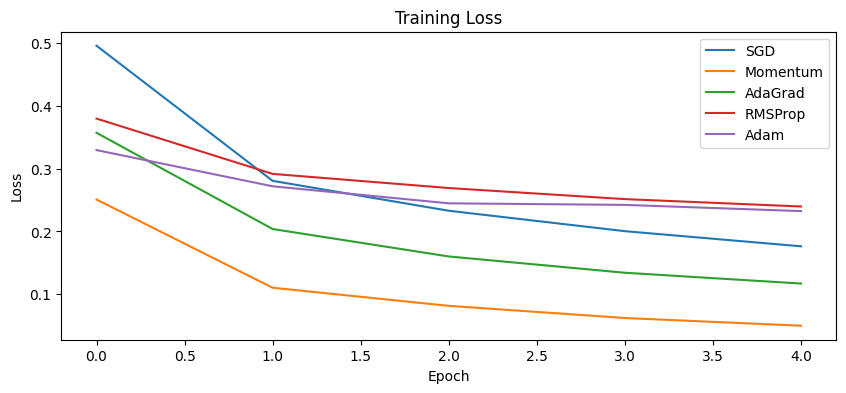

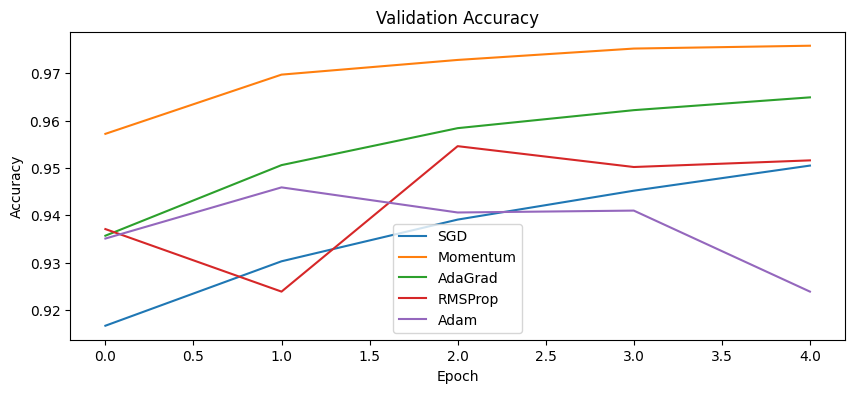

In [9]:
# Loss
plt.figure(figsize=(10, 4))
for name in model_history:
    plt.plot(model_history[name]['loss'], label=f'{name}')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(10, 4))
for name in model_history:
    plt.plot(model_history[name]['val_accuracy'], label=f'{name}')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()